# Especialização em Inteligência Artificial

**Aprendizado de Máquina - Web Conf 1: Exemplos práticos**

Código de exemplo desenvolvido pelo docente [Adriano Rivolli](mailto:rivolli@utpfr.edu.br)

*O código a seguir ilustra como carregar um dataset externo, usar regressores e preencher valores ausentes*

_Webconf: [https://drive.google.com/file/d/1NAfS4HJyx9UpXCLfkJ1lMzo-HcHfjw75/view?usp=sharing](https://drive.google.com/file/d/1NAfS4HJyx9UpXCLfkJ1lMzo-HcHfjw75/view?usp=sharing)_

## Leitura do dataset

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive",force_remount=True)


df = pd.read_csv("/content/drive/MyDrive/UTFPR/aulas/machine learning (especialização)/codigos/webconf/cloud.csv")
df

Mounted at /content/drive


,period,seeded,season,NC,SC,NWC,Target
0,1.0,1,-0.5,1.65,1.80,3.33,1.69
1,2.0,0,-0.5,1.09,0.79,1.59,0.74
2,3.0,1,-1.0,2.39,0.36,2.06,0.81
3,4.0,0,-1.0,2.96,1.27,4.05,1.44
4,5.0,1,-1.0,4.16,2.16,6.00,2.48
...,...,...,...,...,...,...,...
103,190.0,0,0.5,1.38,1.86,2.91,1.36
104,191.0,1,0.5,1.22,2.28,1.58,1.17
105,192.0,0,0.5,2.46,2.47,2.39,2.37
106,193.0,1,0.5,0.05,0.02,0.09,0.02


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Target', axis=1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.head()

,period,seeded,season,NC,SC,NWC
64,117.0,0,-1.0,2.22,0.61,2.68
26,55.0,1,-1.0,0.13,0.59,0.91
22,51.0,0,-0.5,0.52,1.32,2.18
31,60.0,1,-1.0,2.04,0.71,2.22
47,100.0,1,0.5,1.02,1.89,2.47


## Regressores

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

### Knn Regressor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_pred

array([1.23473238, 0.83909379, 0.96608992, 1.54941252, 1.61791421,
       0.98200752, 1.07843532, 0.50155083, 1.57803527, 1.01011079,
       1.47490532, 1.12074041, 0.95570581, 1.2588996 , 0.28424912,
       0.86864006, 0.3709238 , 1.89687403, 0.9109889 , 0.8315381 ,
       0.88707442, 0.57211107])

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2:", r2)

MSE: 1.365058247608193
R2: 0.11986784081570234


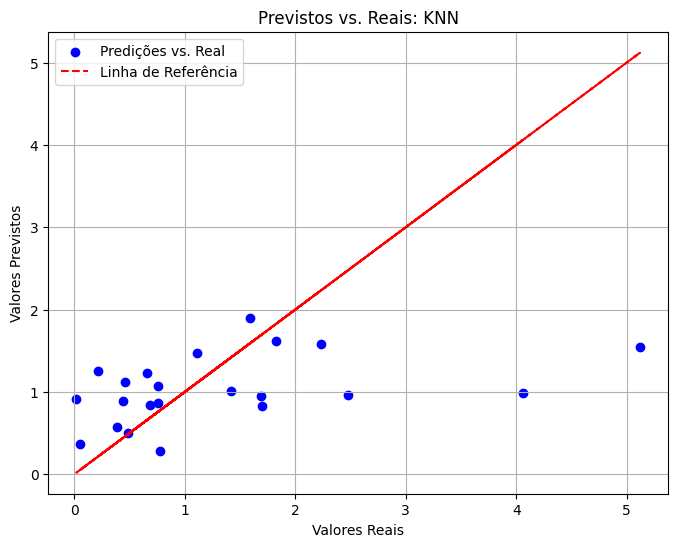

In [ ]:
def plot_predictions_vs_actual(actual, predictions, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(actual, predictions, color='blue', label='Predições vs. Real')
    plt.plot(actual, actual, color='red', linestyle='--', label='Linha de Referência')
    plt.title('Previstos vs. Reais: '+title)
    plt.xlabel('Valores Reais')
    plt.ylabel('Valores Previstos')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_predictions_vs_actual(y_test, y_pred, 'KNN')

### Árvore de regressão

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_pred

array([0.56, 0.4 , 3.43, 6.  , 1.59, 4.97, 1.1 , 0.04, 1.91, 1.08, 0.74,
       0.31, 1.91, 0.  , 0.4 , 0.74, 0.37, 1.36, 0.13, 1.11, 0.42, 0.54])

MSE: 0.18782727272727273
R2: 0.8788968724310425


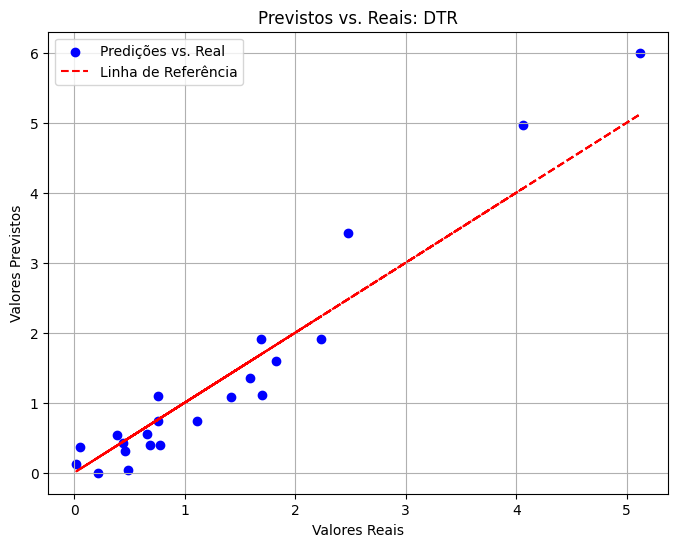

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2:", r2)

plot_predictions_vs_actual(y_test, y_pred, 'DTR')

### SVR

In [ ]:
svr = SVR()
svr.fit(X_train, y_train)

y_pred = svr.predict(X_test)
y_pred

array([1.01870413, 0.84386491, 0.89926767, 1.14826216, 1.02419147,
       1.08280916, 0.81635326, 0.8904933 , 1.18326583, 0.84048524,
       1.04435561, 1.01661749, 0.88260638, 1.01775037, 0.78273193,
       1.01168692, 0.92227261, 1.05050014, 1.13857687, 0.90760832,
       0.82866947, 0.79719108])

MSE: 1.5657943318530414
R2: -0.009558345621530018


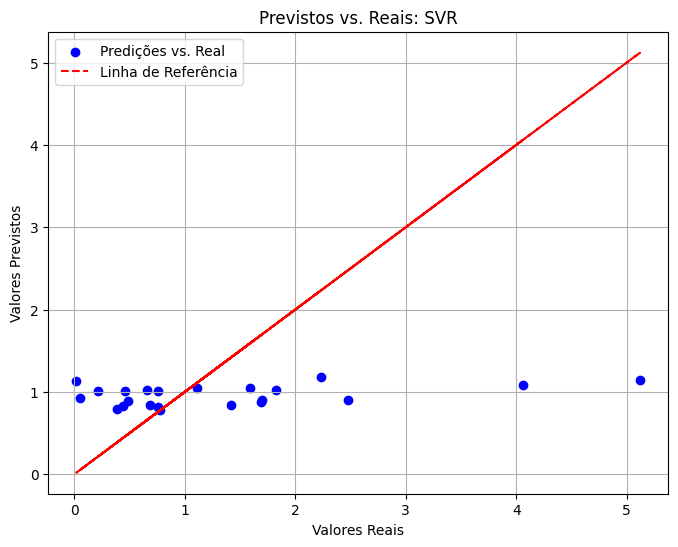

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2:", r2)

plot_predictions_vs_actual(y_test, y_pred, 'SVR')

### Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred

array([0.7859, 0.6865, 2.6852, 3.9275, 2.0795, 3.9805, 1.3813, 0.4821,
       1.9351, 1.037 , 0.789 , 0.3881, 1.7592, 0.1571, 0.4717, 0.7209,
       0.1677, 1.5075, 0.1481, 1.1432, 0.4084, 0.573 ])

MSE: 0.12561110318181787
R2: 0.9190112424472403


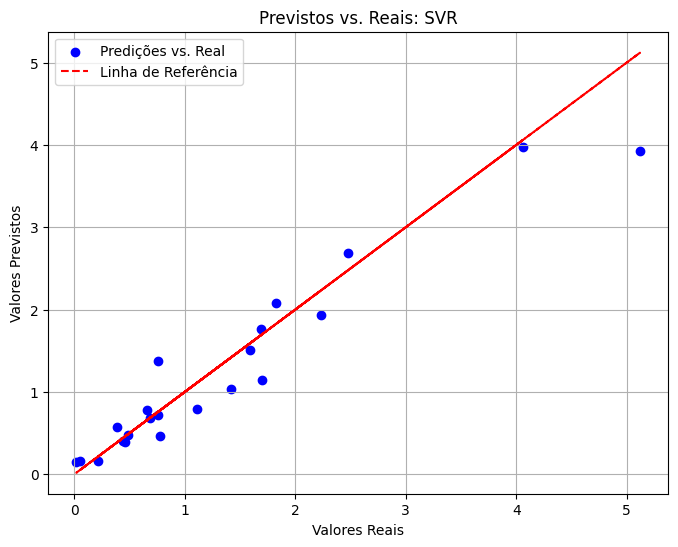

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2:", r2)

plot_predictions_vs_actual(y_test, y_pred, 'SVR')

## Estimando valores ausentes

In [ ]:
import numpy as np

def add_missing_values_to_column(df, column_name, missing_percentage):
    num_instances_with_missing_values = int(len(df) * missing_percentage)
    instances_with_missing_values = np.random.choice(df.index, size=num_instances_with_missing_values, replace=False)

    df_copy = df.copy()
    df_copy.loc[instances_with_missing_values, column_name] = np.nan

    return df_copy

attribute = 'SC'
mdf = add_missing_values_to_column(df, attribute, 0.1)
mdf.loc[mdf.isna().sum(axis=1) > 0,]

,period,seeded,season,NC,SC,NWC,Target
0,1.0,1,-0.5,1.65,NaN,3.33,1.69
3,4.0,0,-1.0,2.96,NaN,4.05,1.44
6,7.0,0,-1.0,1.08,NaN,3.45,0.37
35,64.0,0,0.5,0.66,NaN,0.91,0.54
38,67.0,0,0.5,1.33,NaN,2.18,0.81
43,96.0,1,0.5,2.13,NaN,2.33,1.22
57,110.0,0,-0.5,0.35,NaN,0.20,0.04
75,128.0,1,0.5,2.12,NaN,4.44,2.09
81,134.0,0,1.0,1.32,NaN,1.54,1.11
93,180.0,0,-1.0,1.84,NaN,2.33,2.36


In [ ]:
X = mdf.drop([attribute, 'Target'], axis=1)
y = mdf[attribute]

X_train = X.loc[~y.isna()]
y_train = y.loc[~y.isna()]
X_test = X.loc[y.isna()]
y_test = df.loc[y.isna(), attribute]

X_train.head()

,period,seeded,season,NC,NWC
1,2.0,0,-0.5,1.09,1.59
2,3.0,1,-1.0,2.39,2.06
4,5.0,1,-1.0,4.16,6.00
5,6.0,0,-1.0,2.76,4.17
7,8.0,1,-1.0,0.26,0.90


MSE: 0.24795399799999984
R2: 0.4669043152212009


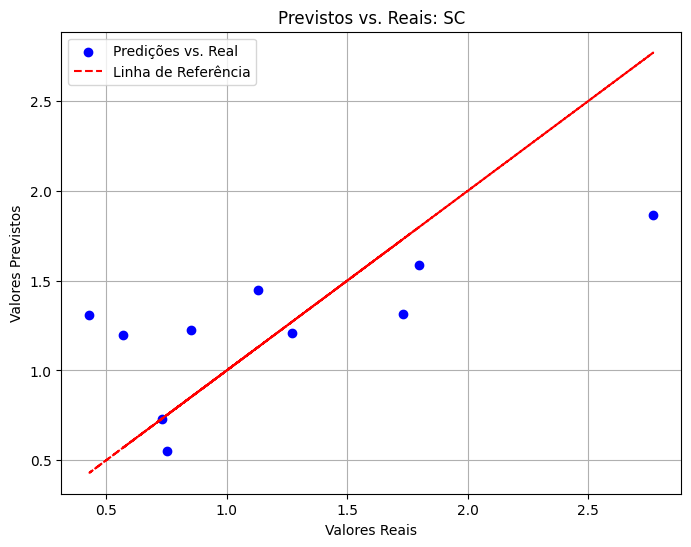

In [ ]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2:", r2)

plot_predictions_vs_actual(y_test, y_pred, attribute)